In [2]:
# from sklearn.model_selection import dateSeriesSplit
from sklearn.model_selection import GridSearchCV
import pandas as pd 
from pathlib import Path
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
master_df = pd.read_parquet("../data/processed/final/master_dataset.parquet").reset_index(drop=True)
master_df.describe()

,Station_Id,t2m,u10,v10,sp,blh,tcc,d2m,skt,AOD,pm25,ssrd,e,tp,latitude,longitude,Elevation,Population_Density
count,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,82171.000000,8.217100e+04,82171.000000,82171.000000,82171.000000,82171.000000,78587.000000,82171.000000
mean,252.320040,298.002264,0.209469,-0.283110,98088.481751,514.399678,0.259031,289.860270,297.854748,0.807785,56.013158,8.288654e+05,-0.000111,0.000037,23.061674,79.313903,247.938590,12652.057617
std,142.840675,5.648328,1.752953,1.299272,2828.548536,243.029782,0.280575,5.773810,6.044034,0.535939,45.719276,1.669750e+05,0.000040,0.000126,5.047615,5.008901,249.291147,14176.642578
min,7.000000,267.248796,-6.169595,-7.819380,73856.258138,51.554948,0.000000,256.504059,260.569289,0.000474,0.130000,9.047267e+04,-0.000394,0.000000,8.510000,71.390000,8.000000,109.036438
25%,127.000000,293.451272,-1.039472,-1.125057,96940.509766,331.762287,0.017546,285.188958,293.003484,0.407781,28.655626,7.053003e+05,-0.000137,0.000000,19.310000,75.860000,50.000000,3471.520752
50%,248.000000,298.798724,0.212102,-0.334312,98670.590169,453.371269,0.156178,289.559917,298.482179,0.660246,44.511111,8.135047e+05,-0.000107,0.000000,23.510000,77.720000,206.000000,8299.075195
75%,370.000000,302.473568,1.507981,0.411401,100176.287598,663.217462,0.420411,294.820395,302.466853,1.084079,68.322917,9.679147e+05,-0.000082,0.000007,26.990000,82.550000,314.000000,16041.125000
max,502.000000,312.291019,8.219025,6.300126,101803.164714,1817.123171,1.000000,301.997050,315.817249,2.997810,842.000000,1.295513e+06,-0.000002,0.003024,34.070000,94.640000,1707.000000,116760.078125


Experimentation window top drop columns

In [4]:
master_df = master_df.drop(columns=[])

Feature engineering 

In [5]:
# convert it to datetime and sort it by time and station id
master_df["date"] = pd.to_datetime(master_df["date"]).dt.date
master_df = master_df.sort_values(by=["Station_Id", "date"]).reset_index(drop=True)

master_df["month"] = pd.to_datetime(master_df["date"]).dt.month
master_df["day"] = pd.to_datetime(master_df["date"]).dt.day
master_df["dayofweek"] = pd.to_datetime(master_df["date"]).dt.dayofweek
master_df["sin_day"] = np.sin(2 * np.pi * master_df["day"] / 31)
master_df["cos_day"] = np.cos(2 * np.pi * master_df["day"] / 31)
master_df["sin_month"] = np.sin(2 * np.pi * master_df["month"] / 12)
master_df["cos_month"] = np.cos(2 * np.pi * master_df["month"] / 12)

master_df["wind_speed"] = np.sqrt(
    master_df["u10"]**2 + master_df["v10"]**2
)

master_df["pollution_trap"] = (
    master_df["AOD"] / (master_df["blh"] + 1)
)

master_df = master_df.drop(columns=["Station_Id"])

In [6]:
train_df = master_df[master_df["date"] > pd.to_datetime("2025-2-01").date()]
test_df = master_df[master_df["date"] <= pd.to_datetime("2025-2-01").date()]

# train_df = master_df[master_df["Station_Id"] > 100]
# test_df = master_df[master_df["Station_Id"] < 100]
train_df

,date,t2m,u10,v10,sp,blh,tcc,d2m,skt,AOD,...,Population_Density,month,day,dayofweek,sin_day,cos_day,sin_month,cos_month,wind_speed,pollution_trap
25,2025-02-02,294.814082,0.511041,-1.280965,99585.347005,334.405831,0.013618,288.542582,294.634663,0.481035,...,10793.390625,2,2,6,3.943559e-01,0.918958,8.660254e-01,0.5,1.379143,0.001434
26,2025-02-03,294.309205,0.868830,-1.684565,99701.849609,409.614848,0.000000,286.816733,293.852773,0.298451,...,10793.390625,2,3,0,5.712682e-01,0.820763,8.660254e-01,0.5,1.895422,0.000727
27,2025-02-04,293.954295,1.338685,-1.493306,99606.399414,362.826460,0.194444,286.768136,293.267162,0.283867,...,10793.390625,2,4,1,7.247928e-01,0.688967,8.660254e-01,0.5,2.005503,0.000780
28,2025-02-05,296.161776,1.210337,-0.957455,99462.248372,319.558797,0.112793,288.862729,295.281498,0.315862,...,10793.390625,2,5,2,8.486443e-01,0.528964,8.660254e-01,0.5,1.543255,0.000985
29,2025-02-06,294.552967,2.089579,-1.886489,99636.661133,480.792957,0.001340,284.181646,293.729693,0.283203,...,10793.390625,2,6,3,9.377521e-01,0.347305,8.660254e-01,0.5,2.815170,0.000588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82166,2025-12-25,287.350435,1.216596,-0.439756,100898.115560,313.883886,0.841053,284.530802,289.427144,2.108633,...,2701.011963,12,25,3,-9.377521e-01,0.347305,-2.449294e-16,1.0,1.293635,0.006697
82167,2025-12-26,287.401140,1.438988,-0.152688,100856.487305,333.183662,0.811709,284.817642,289.312714,0.833291,...,2701.011963,12,26,4,-8.486443e-01,0.528964,-2.449294e-16,1.0,1.447066,0.002494
82168,2025-12-27,286.510171,1.344565,0.013624,100914.325195,312.340154,0.822864,284.020201,288.986932,1.778464,...,2701.011963,12,27,5,-7.247928e-01,0.688967,-2.449294e-16,1.0,1.344634,0.005676
82169,2025-12-30,285.871629,0.489690,0.537331,100711.179688,348.321786,0.259094,283.052821,287.145645,1.845761,...,2701.011963,12,30,1,-2.012985e-01,0.979530,-2.449294e-16,1.0,0.726995,0.005284


In [7]:
test_df

,date,t2m,u10,v10,sp,blh,tcc,d2m,skt,AOD,...,Population_Density,month,day,dayofweek,sin_day,cos_day,sin_month,cos_month,wind_speed,pollution_trap
0,2025-01-08,288.965819,0.563155,-2.047400,99934.877930,403.412771,0.000007,284.456946,288.898282,0.469224,...,10793.390625,1,8,2,9.987165e-01,-0.050649,0.500000,0.866025,2.123438,0.001160
1,2025-01-09,288.648777,0.412589,-1.833967,100165.289714,346.827527,0.000003,284.022895,288.570404,0.907157,...,10793.390625,1,9,3,9.680771e-01,-0.250653,0.500000,0.866025,1.879805,0.002608
2,2025-01-10,288.973080,0.428954,-2.164576,100226.425130,319.032851,0.295728,284.135047,288.631728,0.399888,...,10793.390625,1,10,4,8.978045e-01,-0.440394,0.500000,0.866025,2.206670,0.001250
3,2025-01-11,290.057578,-0.197043,-1.573309,100179.589518,268.867076,0.408089,285.288546,289.452031,0.436418,...,10793.390625,1,11,5,7.907757e-01,-0.612106,0.500000,0.866025,1.585600,0.001617
4,2025-01-12,291.952335,0.211908,-0.515755,100013.017578,259.839854,0.118677,286.624635,290.895365,0.831850,...,10793.390625,1,12,6,6.513725e-01,-0.758758,0.500000,0.866025,0.557592,0.003189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81950,2025-01-28,288.979004,0.963984,0.093904,100591.612305,301.843167,0.011998,284.075756,288.442476,0.440654,...,2701.011963,1,28,1,-5.712682e-01,0.820763,0.500000,0.866025,0.968547,0.001455
81951,2025-01-29,289.315729,-1.162580,0.056493,100640.236003,238.984287,0.113895,284.556870,288.848036,0.313592,...,2701.011963,1,29,2,-3.943559e-01,0.918958,0.500000,0.866025,1.163952,0.001307
81952,2025-01-30,290.770557,1.160102,-0.250720,100277.411784,218.262673,0.104077,285.498651,289.070421,0.284196,...,2701.011963,1,30,3,-2.012985e-01,0.979530,0.500000,0.866025,1.186885,0.001296
81953,2025-01-31,290.964100,-0.006053,-0.069436,100353.722331,221.848195,0.000000,286.267024,290.472825,0.234199,...,2701.011963,1,31,4,-2.449294e-16,1.000000,0.500000,0.866025,0.069700,0.001051


In [8]:
# Define features and target variable
X_train = train_df.drop(columns=["pm25", "date"])
y_train = train_df["pm25"] 

X_test = test_df.drop(columns=["pm25", "date"])
y_test = test_df["pm25"]


In [9]:
model = xgb.XGBRegressor(objective="reg:squarederror", 
                         n_estimators=200, 
                         learning_rate=0.5, 
                         max_depth=6, 
                         random_state=42,
                         n_jobs=2)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [10]:
# #tuing the model using GridSearchCV
# param_grid = {
#     "n_estimators": [100, 300],
#     "max_depth": [4, 6, 8],
#     "learning_rate": [0.03, 0.05, 0.1],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

# grid = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=3,
#     scoring="r2",
#     verbose=1,
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

# print(grid.best_params_)

# best_model = grid.best_estimator_

In [11]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"RMSE: {np.sqrt(mse)}")
print(f"MAE: {np.mean(np.abs(y_test - y_pred))}")

Mean Squared Error: 1170.5206712499612
R^2 Score: 0.4580682161053439
RMSE: 34.21287288799292
MAE: 21.944417553302173


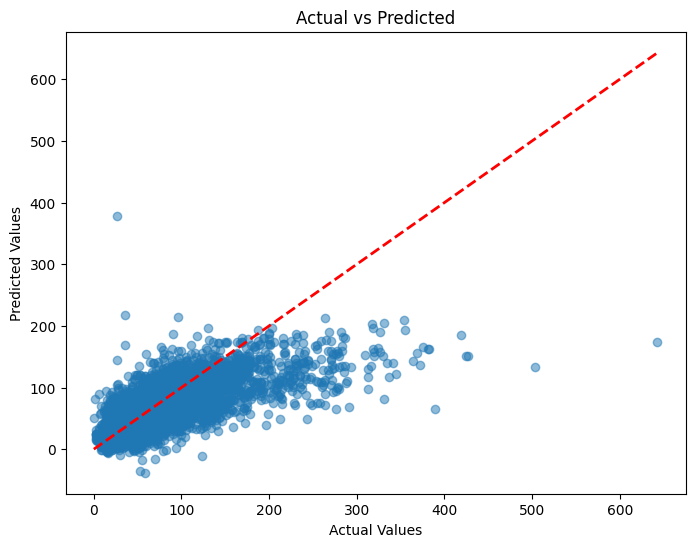

In [12]:
# Assuming y_test is your actual data and y_pred is your model's prediction
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add a diagonal line for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

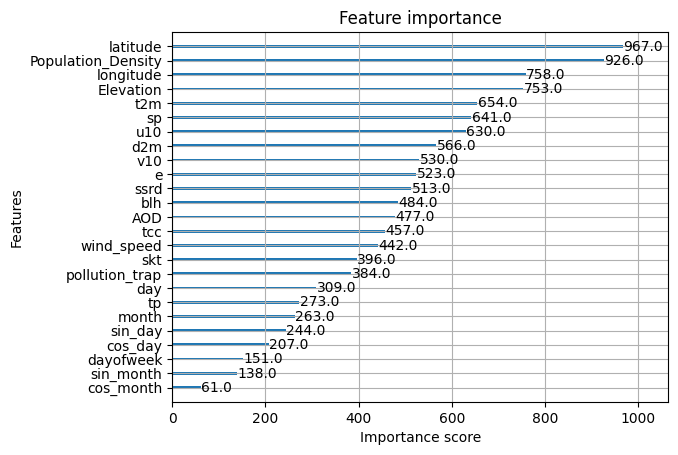

In [13]:
xgb.plot_importance(model)

In [15]:
import joblib

joblib.dump(
    model,
    "../results/model_v1.pkl"
)

['../results/model_v1.pkl']

In [17]:
import json

with open(
    "../results/xgboost_params.json",
    "w"
) as f:

    json.dump(
        model.get_params(),
        f,
        indent=4
    )